In [1]:
import pandas as pd
import glob

file = glob.glob("*.csv")
df = pd.read_csv(file[0])
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [2]:
crosstab = pd.crosstab(df['category'], df['isBestSeller'])
crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [3]:
crosstab_prop = crosstab.div(crosstab.sum(axis=1), axis=0)
sorted_best_seller_rate = crosstab_prop.sort_values(by=True, ascending=False)  # If best-seller status is True
sorted_best_seller_rate

isBestSeller,False,True
category,,
Grocery,0.941865,0.058135
Smart Home Security & Lighting,0.942308,0.057692
Health & Personal Care,0.942314,0.057686
Mobile Phone Accessories,0.957529,0.042471
Power & Hand Tools,0.964661,0.035339
...,...,...
"CD, Disc & Tape Players",1.000000,0.000000
General Music-Making Accessories,1.000000,0.000000
Snowboard Boots,1.000000,0.000000


In [4]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p}")

Chi-square statistic: 36540.20270061387
p-value: 0.0


In [5]:
import numpy as np

n = crosstab.values.sum()import matplotlib.pyplot as plt

crosstab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Best-Seller Distribution Across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Number of Products')
plt.legend(title='Is Best Seller', loc='upper right')
plt.tight_layout()
plt.show()
phi2 = chi2 / n
r, k = crosstab.shape
cramers_v = np.sqrt(phi2 / min(k-1, r-1))
print(f"Cramér's V: {cramers_v}")

Cramér's V: 0.1222829439760564


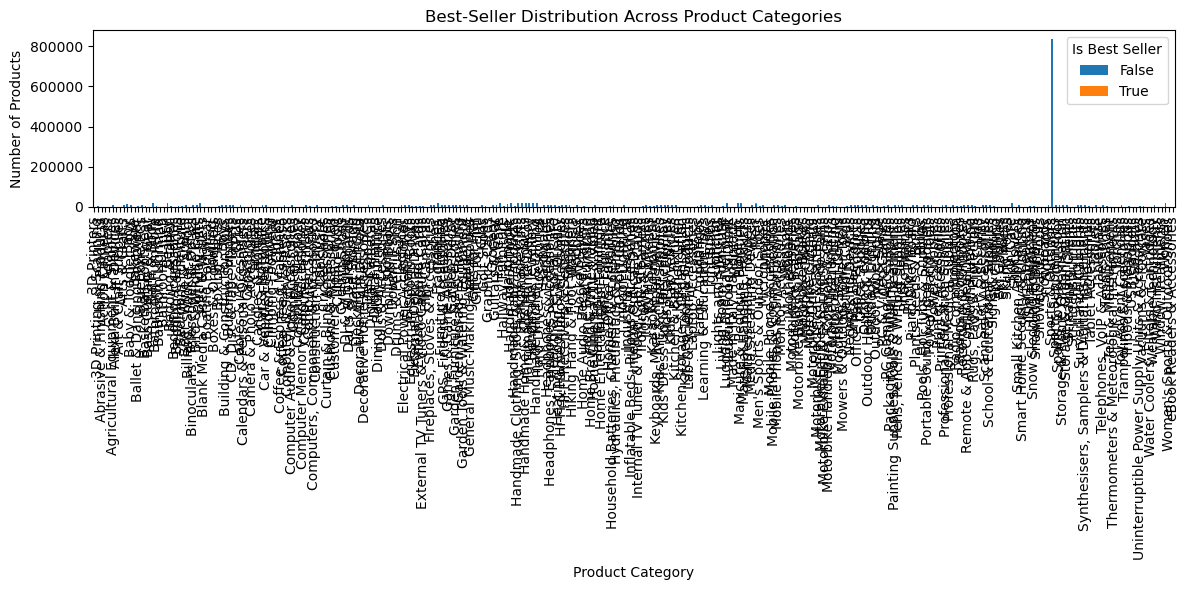

In [6]:
import matplotlib.pyplot as plt

crosstab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Best-Seller Distribution Across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Number of Products')
plt.legend(title='Is Best Seller', loc='upper right')
plt.tight_layout()
plt.show()

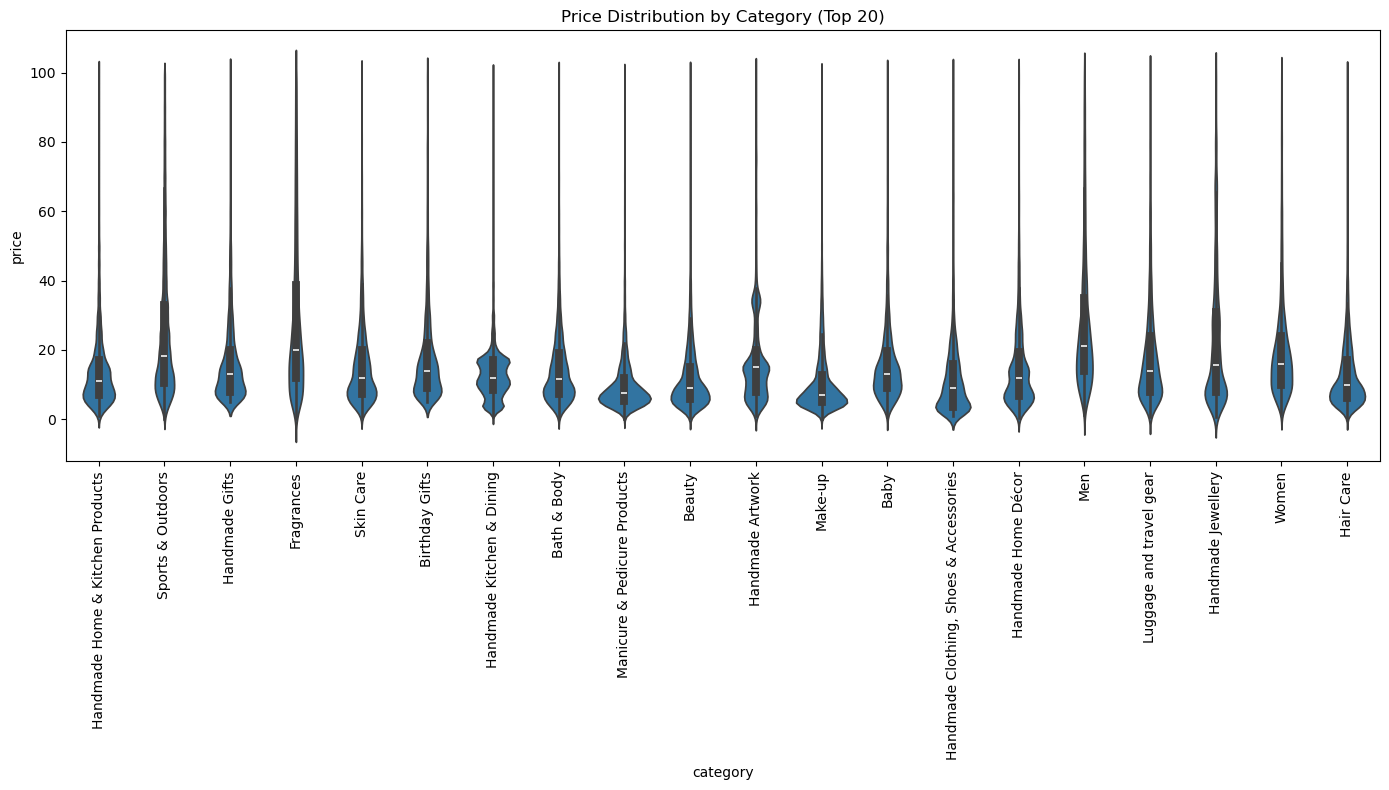

In [8]:
# Calculate Q1, Q3, and IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 20 categories
top_20_categories = df_clean['category'].value_counts().head(20).index

# Filter dataset
df_violin = df_clean[df_clean['category'].isin(top_20_categories)]

# Plot
plt.figure(figsize=(14, 8))
sns.violinplot(x='category', y='price', data=df_violin)
plt.xticks(rotation=90)
plt.title('Price Distribution by Category (Top 20)')
plt.tight_layout()
plt.show()

Category with highest median price: Desktop PCs (£74.00)


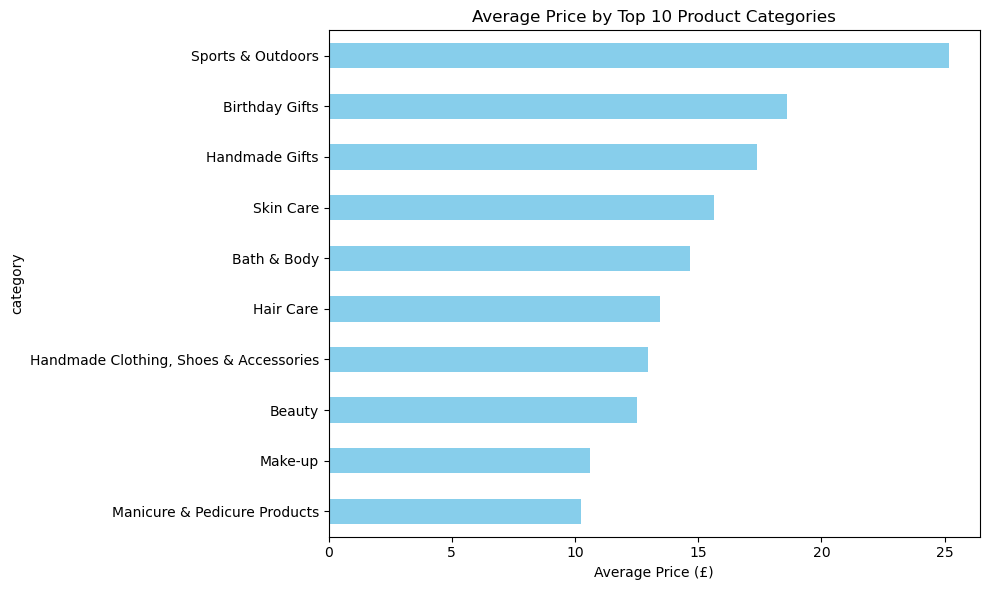

Category with highest average price: Sports & Outdoors (£25.17)


In [10]:
median_prices = df_clean.groupby('category')['price'].median().sort_values(ascending=False)
highest_median_category = median_prices.idxmax()
print(f"Category with highest median price: {highest_median_category} (£{median_prices.max():.2f})")
top_10_categories = df_clean['category'].value_counts().head(10).index
avg_prices = df_clean[df_clean['category'].isin(top_10_categories)].groupby('category')['price'].mean()

# Plot
avg_prices.sort_values().plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Average Price by Top 10 Product Categories')
plt.xlabel('Average Price (£)')
plt.tight_layout()
plt.show()

highest_avg_category = avg_prices.idxmax()
print(f"Category with highest average price: {highest_avg_category} (£{avg_prices.max():.2f})")

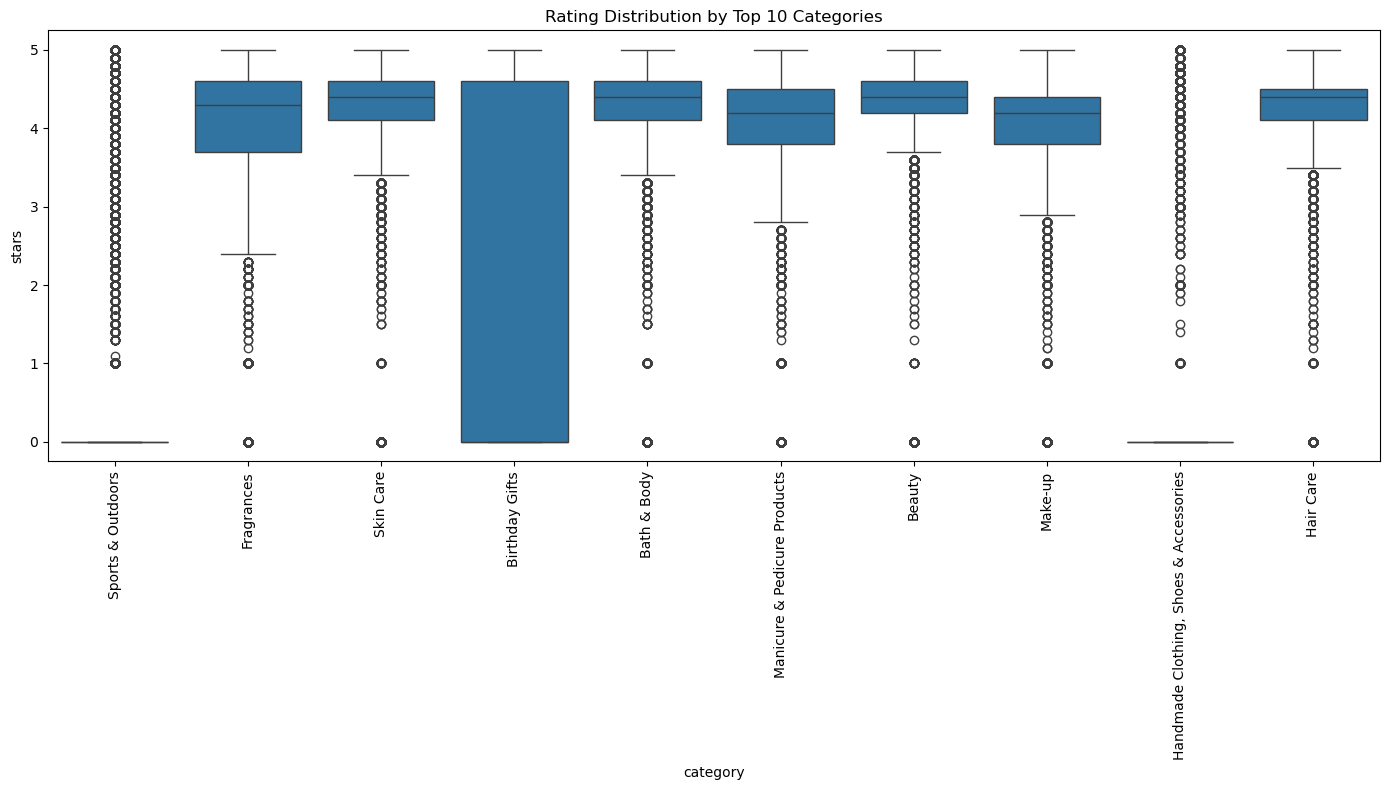

Category with highest median rating: Computer Memory (4.7)


In [14]:
# Make sure 'rating' column exists and is numeric
if 'stars' in df.columns:
    df['stars'] = pd.to_numeric(df['stars'], errors='coerce')  # Optional: convert to numeric

    top_10_stars_categories = df['category'].value_counts().head(10).index
    df_rating = df[df['category'].isin(top_10_stars_categories)]

    plt.figure(figsize=(14, 8))
    sns.boxplot(x='category', y='stars', data=df_rating)
    plt.xticks(rotation=90)
    plt.title('Rating Distribution by Top 10 Categories')
    plt.tight_layout()
    plt.show()

    median_ratings = df.groupby('category')['stars'].median().dropna().sort_values(ascending=False)
    print(f"Category with highest median rating: {median_ratings.idxmax()} ({median_ratings.max()})")
else:
    print("Column 'stars' not found in dataset.")

In [16]:
import pandas as pd
import numpy as np

# Convert columns to numeric (if not already)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['stars'] = pd.to_numeric(df['stars'], errors='coerce')

# Drop rows with missing price or rating
df_corr = df[['price', 'stars']].dropna()
correlation = df_corr['price'].corr(df_corr['stars'])
print(f"Correlation between price and stars: {correlation:.3f}")

Correlation between price and stars: -0.125


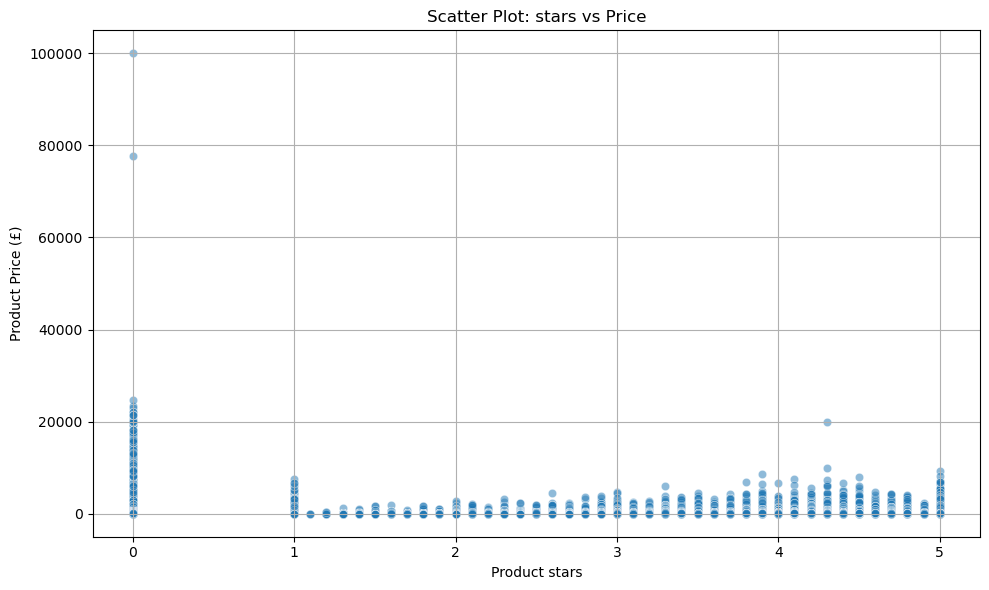

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='stars', y='price', data=df_corr, alpha=0.5)
plt.title('Scatter Plot: stars vs Price')
plt.xlabel('Product stars')
plt.ylabel('Product Price (£)')
plt.grid(True)
plt.tight_layout()
plt.show()

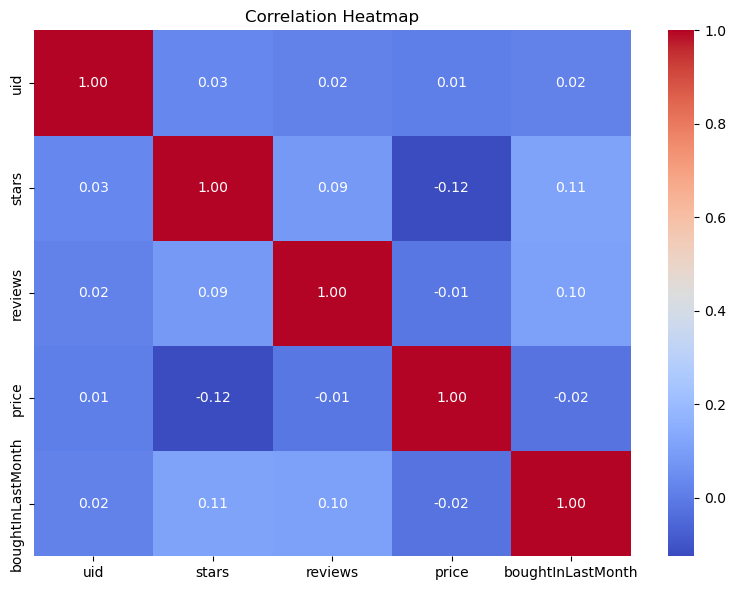

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

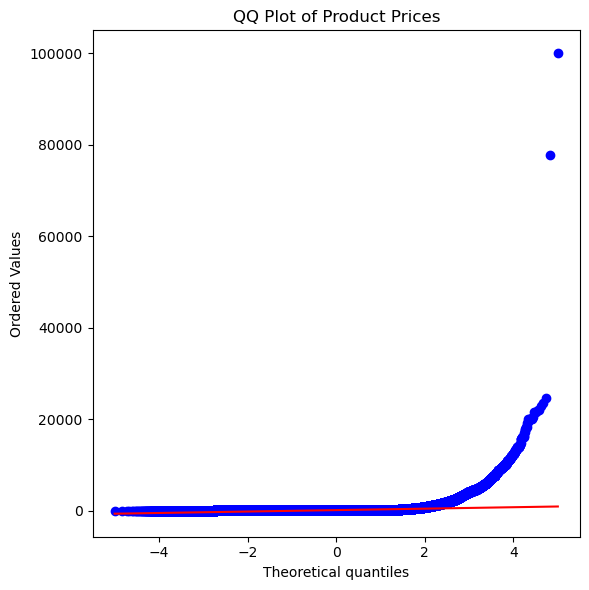

In [20]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
stats.probplot(df_corr['price'], dist="norm", plot=plt)
plt.title("QQ Plot of Product Prices")
plt.tight_layout()
plt.show()

According to the statistical analysis, I observed an inverse relationship between product categories and the number of products. The number of products is insufficient in line with the product categories. 

Meanwhile, according to the top 20 categories on the violin plot, I observed a slight or insignificant price variation, which indicates that the articles are equally valuable. 

According to the Bar chart, the category with the highest median price is desktop, while the one with the highest price is sports and outdoors. 

According to the scatter plot, most of the products have stars with an average price of less than £20,000.